# 1. Time-Based Train / Validation Split

## Objective

Since this is a retail demand forecasting problem, the model must be evaluated on future observations rather than randomly selected observations.

A chronological train-validation split is therefore used to simulate a real-world forecasting scenario:

- Training data → historical observations available before the cutoff date.
- Validation data → future observations after the cutoff date.

This prevents future observations from being randomly introduced into the training data and provides a more realistic estimate of forecasting performance.

### Business Question

How accurately can the model predict future store sales using only historical information available before the prediction period?

In [1]:
import pandas as pd

model_df = pd.read_csv(
    "../data/processed/model_data.csv",
    parse_dates=["Date"]
)

In [2]:
print(model_df.shape)
print(model_df["Date"].min())
print(model_df["Date"].max())

(983759, 33)
2013-01-31 00:00:00
2015-07-31 00:00:00


In [3]:
cutoff_date = pd.Timestamp("2015-05-31")

train_df = model_df[model_df["Date"] <= cutoff_date].copy()
val_df = model_df[model_df["Date"] > cutoff_date].copy()

print("Training shape:", train_df.shape)
print("Validation shape:", val_df.shape)

print("\nTraining period:")
print(train_df["Date"].min(), "→", train_df["Date"].max())

print("\nValidation period:")
print(val_df["Date"].min(), "→", val_df["Date"].max())

Training shape: (915744, 33)
Validation shape: (68015, 33)

Training period:
2013-01-31 00:00:00 → 2015-05-31 00:00:00

Validation period:
2015-06-01 00:00:00 → 2015-07-31 00:00:00


In [4]:
feature_cols = [
    col for col in model_df.columns
    if col not in ["Sales", "Date"]
]

#here we exclude sales and date column specifically because sales column is our target variable that connot go 
# into our feature training inputs(it wil cause a data leakage)
#date column is excluded because it is in the form of datetime stamps object which cannot be processed by 
#traditional ML algorithms like xgboost.

In [5]:
X_train = train_df[feature_cols]
X_val = val_df[feature_cols]

y_train = train_df["Sales"] # y_train contains the target variable in training period
y_val = val_df["Sales"] # y_val contains the target variable in the validation period

In [6]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)

X_train: (915744, 31)
X_val: (68015, 31)
y_train: (915744,)
y_val: (68015,)


In [7]:
print("Training target mean:", y_train.mean())
print("Validation target mean:", y_val.mean())

Training target mean: 5766.26995754272
Validation target mean: 6170.491641549658


In [8]:
print(X_train.dtypes.value_counts())

non_numeric_cols = X_train.select_dtypes(
    exclude="number"
).columns.tolist()

print("Non-numeric columns:", non_numeric_cols)

print("Missing values in X_train:", X_train.isnull().sum().sum())
print("Missing values in X_val:", X_val.isnull().sum().sum())

print("Same columns:", list(X_train.columns) == list(X_val.columns))

print(feature_cols)

int64      23
float64     8
Name: count, dtype: int64
Non-numeric columns: []
Missing values in X_train: 0
Missing values in X_val: 0
Same columns: True
['Store', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear', 'CompetitionOpenMonths', 'Promo2Active', 'IsStateHoliday', 'StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b', 'Assortment_c', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'Sales_Lag_1', 'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Rolling_7', 'Sales_Rolling_14', 'Sales_Rolling_30']


In [9]:
print(
    X_train[
        [
            "Sales_Lag_1",
            "Sales_Lag_7",
            "Sales_Lag_14",
            "Sales_Rolling_7",
            "Sales_Rolling_14",
            "Sales_Rolling_30"
        ]
    ].head(10)
)

   Sales_Lag_1  Sales_Lag_7  Sales_Lag_14  Sales_Rolling_7  Sales_Rolling_14  \
0       4601.0       5195.0        4044.0      4108.571429       4200.357143   
1       4709.0       5586.0        4127.0      4039.142857       4247.857143   
2       5633.0       5598.0        5182.0      4045.857143       4355.428571   
3       5970.0          0.0           0.0      4099.000000       4411.714286   
4          0.0       4055.0        5394.0      4099.000000       4411.714286   
5       7032.0       3725.0        5720.0      4524.285714       4528.714286   
6       6049.0       4601.0        5578.0      4856.285714       4552.214286   
7       6140.0       4709.0        5195.0      5076.142857       4592.357143   
8       5499.0       5633.0        5586.0      5189.000000       4614.071429   
9       5681.0       5970.0        5598.0      5195.857143       4620.857143   

   Sales_Rolling_30  
0       4124.066667  
1       4281.033333  
2       4284.466667  
3       4339.233333  
4       4

In [10]:
print(
    X_val[
        [
            "Sales_Lag_1",
            "Sales_Lag_7",
            "Sales_Lag_14",
            "Sales_Rolling_7",
            "Sales_Rolling_14",
            "Sales_Rolling_30"
        ]
    ].head(10)
)

     Sales_Lag_1  Sales_Lag_7  Sales_Lag_14  Sales_Rolling_7  \
851          0.0          0.0        5280.0      3236.142857   
852       5774.0       4211.0        5235.0      4061.000000   
853       5450.0       4083.0        4735.0      4238.000000   
854       5809.0       4111.0        3755.0      4484.571429   
855          0.0       4656.0        4459.0      3897.285714   
856       5384.0       5592.0        4276.0      4001.285714   
857       4183.0          0.0           0.0      3800.000000   
858          0.0       5774.0           0.0      3800.000000   
859       4071.0       5450.0        4211.0      3556.714286   
860       4102.0       5809.0        4083.0      3364.142857   

     Sales_Rolling_14  Sales_Rolling_30  
851       3599.500000       3507.333333  
852       3634.785714       3504.800000  
853       3650.142857       3686.466667  
854       3726.857143       3693.733333  
855       3458.642857       3541.600000  
856       3524.714286       3555.733333  
8

## 4. Baseline XGBoost Model

The first model uses XGBoost for one-step-ahead store sales forecasting.

The forecasting setup assumes that the model predicts the next day's sales using information available up to the current day, including recently observed sales through lag and rolling features.

No extensive hyperparameter tuning is performed at this stage. The objective is to establish a reliable baseline against which future improvements can be compared.

In [11]:
import xgboost as xgb



In [12]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=8,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
    random_state=42,
    n_jobs=-1
)

In [13]:
model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'rmse'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [14]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Original predictions
y_pred_raw = model.predict(X_val)

# Business-valid predictions
y_pred = np.maximum(y_pred_raw, 0)

mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
r2 = r2_score(y_val, y_pred)

wape = np.sum(np.abs(y_val - y_pred)) / np.sum(np.abs(y_val)) * 100

print("One-Step Ahead Forecasting Performance")
print("---------------------------------------")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"WAPE : {wape:.2f}%")
print(f"R²   : {r2:.4f}")

One-Step Ahead Forecasting Performance
---------------------------------------
MAE  : 495.29
RMSE : 752.05
WAPE : 8.03%
R²   : 0.9609


In [15]:
print("Actual Sales:")
print(y_val.iloc[:10].values)

print("\nPredicted Sales:")
print(y_pred[:10])

Actual Sales:
[5774 5450 5809    0 5384 4183    0 4071 4102 3591]

Predicted Sales:
[6830.968    5776.5083   5194.7915      0.       6645.408    4525.3525
   50.372932 3960.2415   3834.6611   3974.3855  ]


# 3. Rolling Window Forecasting

## Objective

Evaluate the model using a rolling-window forecasting strategy in which a fixed amount of historical data is used for training and the training window moves forward through time.

Unlike the one-step-ahead baseline, the rolling-window approach evaluates model performance across multiple successive forecasting periods while maintaining a fixed historical training window.

## Business Question

How well can the demand forecasting model perform when it is repeatedly retrained using a fixed window of the most recent historical observations?

# 3. Rolling-Window Forecasting

Rolling-window forecasting uses a fixed amount of recent historical data for model training.

The training window moves forward through time while maintaining the same window size. This allows the model to focus on relatively recent demand patterns while avoiding excessive influence from very old observations.

For this project:

- Training window: 365 days
- Forecast horizon: 30 days
- Window movement: 30 days

The rolling-window strategy will first be evaluated using historical development data through rolling backtesting.

The final test period (June–July 2015) will remain untouched until the final comparison of forecasting strategies.

## 3.1 Development and Final Test Period

To ensure a fair comparison between the three forecasting strategies, the same final test period will be used for:

1. One-Step-Ahead Forecasting
2. Rolling-Window Forecasting
3. Expanding-Window Forecasting

The period from June 1, 2015 to July 31, 2015 is reserved as the final test set.

No model-selection or forecasting-strategy decisions will be based on this final test period.

In [16]:
# Define the final test period

final_test_start = pd.Timestamp("2015-06-01")
final_test_end = pd.Timestamp("2015-07-31")

# Development data
development_df = model_df[
    model_df["Date"] < final_test_start
].copy()

# Final test data
final_test_df = model_df[
    (model_df["Date"] >= final_test_start) &
    (model_df["Date"] <= final_test_end)
].copy()

print("Development period:")
print(development_df["Date"].min(), "→", development_df["Date"].max())

print("\nFinal test period:")
print(final_test_df["Date"].min(), "→", final_test_df["Date"].max())

print("\nDevelopment shape:", development_df.shape)
print("Final test shape:", final_test_df.shape)

Development period:
2013-01-31 00:00:00 → 2015-05-31 00:00:00

Final test period:
2015-06-01 00:00:00 → 2015-07-31 00:00:00

Development shape: (915744, 33)
Final test shape: (68015, 33)


In [17]:
ROLLING_TRAIN_DAYS = 365
ROLLING_FORECAST_DAYS = 30
ROLLING_STEP_DAYS = 30

print(f"Training window : {ROLLING_TRAIN_DAYS} days")
print(f"Forecast horizon: {ROLLING_FORECAST_DAYS} days")
print(f"Window step     : {ROLLING_STEP_DAYS} days")

Training window : 365 days
Forecast horizon: 30 days
Window step     : 30 days


In [18]:
development_start = development_df["Date"].min()
development_end = development_df["Date"].max()

first_forecast_start = (
    development_start +
    pd.Timedelta(days=ROLLING_TRAIN_DAYS)
)

print("Development start :", development_start)
print("Development end   :", development_end)
print("First forecast    :", first_forecast_start)

Development start : 2013-01-31 00:00:00
Development end   : 2015-05-31 00:00:00
First forecast    : 2014-01-31 00:00:00


In [19]:
# Check observations per store in the development data

obs_per_store = (
    development_df
    .groupby("Store")
    .size()
)

print(obs_per_store.describe())

print("\nMinimum observations:", obs_per_store.min())
print("Maximum observations:", obs_per_store.max())

count    1115.000000
mean      821.295067
std        67.729422
min       667.000000
25%       851.000000
50%       851.000000
75%       851.000000
max       851.000000
dtype: float64

Minimum observations: 667
Maximum observations: 851


In [20]:
# Check whether each store has roughly daily observations

store_date_counts = (
    development_df
    .groupby("Store")["Date"]
    .agg(["min", "max", "count"])
)

print(store_date_counts.head(10))

             min        max  count
Store                             
1     2013-01-31 2015-05-31    851
2     2013-01-31 2015-05-31    851
3     2013-01-31 2015-05-31    851
4     2013-01-31 2015-05-31    851
5     2013-01-31 2015-05-31    851
6     2013-01-31 2015-05-31    851
7     2013-01-31 2015-05-31    851
8     2013-01-31 2015-05-31    851
9     2013-01-31 2015-05-31    851
10    2013-01-31 2015-05-31    851


In [21]:
# Customers is not available at the time of a genuine future forecast.
# Therefore, remove it from the model features.

if "Customers" in feature_cols:
    feature_cols.remove("Customers")

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 31
['Store', 'DayOfWeek', 'Open', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear', 'CompetitionOpenMonths', 'Promo2Active', 'IsStateHoliday', 'StoreType_a', 'StoreType_b', 'StoreType_c', 'StoreType_d', 'Assortment_a', 'Assortment_b', 'Assortment_c', 'StateHoliday_0', 'StateHoliday_a', 'StateHoliday_b', 'StateHoliday_c', 'Sales_Lag_1', 'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Rolling_7', 'Sales_Rolling_14', 'Sales_Rolling_30']


In [22]:
sales_history_features = [
    "Sales_Lag_1",
    "Sales_Lag_7",
    "Sales_Lag_14",
    "Sales_Rolling_7",
    "Sales_Rolling_14",
    "Sales_Rolling_30"
]

print(sales_history_features)

['Sales_Lag_1', 'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Rolling_7', 'Sales_Rolling_14', 'Sales_Rolling_30']


In [23]:
ROLLING_TRAIN_DAYS = 365
HORIZON = 30
STEP = 30

rolling_folds = []

forecast_start = first_forecast_start

while True:

    # Calculates the end date for the 30-day evaluation window. Subtracting 1 day ensures the start and 
    # end dates form an inclusive 30-day period
    forecast_end = (
        forecast_start
        + pd.Timedelta(days=HORIZON - 1)
    )

    # Checks if the forecast end date extends past the last available date in your dataset (development_end). 
    # If it does, the loop terminates immediately so you do not evaluate on missing/incomplete future data.
    if forecast_end > development_end:
        break

    # Determines the training start date by looking back exactly 365 days from the forecast start date.
    train_start = (
        forecast_start
        - pd.Timedelta(days=ROLLING_TRAIN_DAYS)
    )
    # Sets the training end date to the day right before forecast_start, preventing data leakage into the 
    # test set.
    train_end = (
        forecast_start
        - pd.Timedelta(days=1)
    )
    # Saves the calculated four date boundaries (train_start, train_end, forecast_start, forecast_end) as a 
    # dictionary inside the rolling_folds list.
    rolling_folds.append({
        "train_start": train_start,
        "train_end": train_end,
        "forecast_start": forecast_start,
        "forecast_end": forecast_end
    })

    # Advances the start date of the evaluation window by 30 days to prepare for building the next fold
    forecast_start = (
        forecast_start
        + pd.Timedelta(days=STEP)
    )

print(
    "Number of rolling folds:",
    len(rolling_folds)
)

Number of rolling folds: 16


In [24]:
for i, fold in enumerate(rolling_folds[:5], start=1):

    print(f"\nFold {i}")

    print(
        "Training :",
        fold["train_start"],
        "→",
        fold["train_end"]
    )

    print(
        "Forecast :",
        fold["forecast_start"],
        "→",
        fold["forecast_end"]
    )


Fold 1
Training : 2013-01-31 00:00:00 → 2014-01-30 00:00:00
Forecast : 2014-01-31 00:00:00 → 2014-03-01 00:00:00

Fold 2
Training : 2013-03-02 00:00:00 → 2014-03-01 00:00:00
Forecast : 2014-03-02 00:00:00 → 2014-03-31 00:00:00

Fold 3
Training : 2013-04-01 00:00:00 → 2014-03-31 00:00:00
Forecast : 2014-04-01 00:00:00 → 2014-04-30 00:00:00

Fold 4
Training : 2013-05-01 00:00:00 → 2014-04-30 00:00:00
Forecast : 2014-05-01 00:00:00 → 2014-05-30 00:00:00

Fold 5
Training : 2013-05-31 00:00:00 → 2014-05-30 00:00:00
Forecast : 2014-05-31 00:00:00 → 2014-06-29 00:00:00


In [25]:
import numpy as np
import pandas as pd


def recursive_forecast(
    model,
    historical_df,
    future_df,
    feature_cols
):


    sales_pivot = historical_df.pivot(
        index="Date", columns="Store", values="Sales"
    )

    all_stores = future_df["Store"].unique()
    missing_stores = set(all_stores) - set(sales_pivot.columns)
    for s in missing_stores:
        sales_pivot[s] = np.nan
    sales_pivot = sales_pivot.sort_index(axis=1)

    forecast_dates = sorted(future_df["Date"].unique())


    def get_lag(date, offset_days, stores):
        target_date = date - pd.Timedelta(days=offset_days)
        if target_date in sales_pivot.index:
            return sales_pivot.loc[target_date, stores].values
        return np.full(len(stores), np.nan)

    def get_rolling_mean(date, window, stores):
        window_dates = [
            date - pd.Timedelta(days=i) for i in range(1, window + 1)
        ]
        window_dates = [d for d in window_dates if d in sales_pivot.index]
        if not window_dates:
            return np.full(len(stores), np.nan)
        sub = sales_pivot.loc[window_dates, stores]
        return sub.mean(axis=0, skipna=True).values

    prediction_frames = []

    for date in forecast_dates:

        day_rows = future_df[future_df["Date"] == date].copy()
        stores_today = day_rows["Store"].values

        day_rows["Sales_Lag_1"] = get_lag(date, 1, stores_today)
        day_rows["Sales_Lag_7"] = get_lag(date, 7, stores_today)
        day_rows["Sales_Lag_14"] = get_lag(date, 14, stores_today)

        day_rows["Sales_Rolling_7"] = get_rolling_mean(date, 7, stores_today)
        day_rows["Sales_Rolling_14"] = get_rolling_mean(date, 14, stores_today)
        day_rows["Sales_Rolling_30"] = get_rolling_mean(date, 30, stores_today)

        X_day = day_rows[feature_cols]

        #single batched predict() call for the whole day
        preds_today = model.predict(X_day)

        # Write today's predictions back into the pivot so that LATER
        # dates in this same forecast horizon can use them as lags.
        if date not in sales_pivot.index:
            sales_pivot.loc[date] = np.nan
        sales_pivot.loc[date, stores_today] = preds_today

        day_rows["Predicted_Sales"] = preds_today
        prediction_frames.append(day_rows[["Store", "Date", "Predicted_Sales"]])


    all_preds = pd.concat(prediction_frames, ignore_index=True)

    aligned = future_df[["Store", "Date"]].merge(
        all_preds, on=["Store", "Date"], how="left"
    )

    return aligned["Predicted_Sales"].values

In [26]:
rolling_results = []
all_predictions = []

for fold_number, fold in enumerate(
    rolling_folds,
    start=1
):

    print(
        f"\n========== Fold "
        f"{fold_number}/{len(rolling_folds)} =========="
    )

    train_start = fold["train_start"]
    train_end = fold["train_end"]

    forecast_start = fold["forecast_start"]
    forecast_end = fold["forecast_end"]


    fold_train = development_df[
        (development_df["Date"] >= train_start) &
        (development_df["Date"] <= train_end)
    ].copy()

    fold_future = development_df[
        (development_df["Date"] >= forecast_start) &
        (development_df["Date"] <= forecast_end)
    ].copy()

    print(
        "Training:",
        train_start.date(),
        "→",
        train_end.date()
    )

    print(
        "Forecast:",
        forecast_start.date(),
        "→",
        forecast_end.date()
    )

    print("Training rows:", len(fold_train))
    print("Forecast rows:", len(fold_future))


    X_train_fold = fold_train[feature_cols]
    y_train_fold = fold_train["Sales"]


    model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        min_child_weight=5,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        eval_metric="rmse",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    )


    # Fit ONCE for this entire 30-day horizon

    model.fit(
        X_train_fold,
        y_train_fold,
        verbose=False
    )

   
    # Forecast the ENTIRE 30-day horizon
  
    y_pred_fold = recursive_forecast(
        model=model,
        historical_df=fold_train,
        future_df=fold_future,
        feature_cols=feature_cols
    )


    # Actual sales
    y_actual_fold = fold_future["Sales"].values

    mae = mean_absolute_error(
        y_actual_fold,
        y_pred_fold
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_actual_fold,
            y_pred_fold
        )
    )

    wape = (
        np.sum(
            np.abs(
                y_actual_fold - y_pred_fold
            )
        )
        /
        np.sum(
            np.abs(y_actual_fold)
        )
    ) * 100

    r2 = r2_score(
        y_actual_fold,
        y_pred_fold
    )

    # Store fold metrics
    

    rolling_results.append({
        "Fold": fold_number,
        "Train_Start": train_start,
        "Train_End": train_end,
        "Forecast_Start": forecast_start,
        "Forecast_End": forecast_end,
        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape,
        "R2": r2
    })

    # Store individual predictions

    fold_predictions = fold_future[
        ["Store", "Date", "Sales"]
    ].copy()

    fold_predictions["Predicted_Sales"] = y_pred_fold
    fold_predictions["Fold"] = fold_number

    all_predictions.append(
        fold_predictions
    )

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"WAPE : {wape:.2f}%")
    print(f"R²   : {r2:.4f}")


========== Fold 1/16 ==========
Training: 2013-01-31 → 2014-01-30
Forecast: 2014-01-31 → 2014-03-01
Training rows: 406974
Forecast rows: 33450
MAE  : 527.40
RMSE : 770.58
WAPE : 9.10%
R²   : 0.9521

========== Fold 2/16 ==========
Training: 2013-03-02 → 2014-03-01
Forecast: 2014-03-02 → 2014-03-31
Training rows: 406975
Forecast rows: 33450
MAE  : 569.54
RMSE : 965.10
WAPE : 10.25%
R²   : 0.9320

========== Fold 3/16 ==========
Training: 2013-04-01 → 2014-03-31
Forecast: 2014-04-01 → 2014-04-30
Training rows: 406975
Forecast rows: 33450
MAE  : 858.62
RMSE : 1305.36
WAPE : 14.76%
R²   : 0.8960

========== Fold 4/16 ==========
Training: 2013-05-01 → 2014-04-30
Forecast: 2014-05-01 → 2014-05-30
Training rows: 406975
Forecast rows: 33450
MAE  : 584.65
RMSE : 862.82
WAPE : 10.41%
R²   : 0.9498

========== Fold 5/16 ==========
Training: 2013-05-31 → 2014-05-30
Forecast: 2014-05-31 → 2014-06-29
Training rows: 406975
Forecast rows: 33450
MAE  : 570.59
RMSE : 866.34
WAPE : 10.39%
R²   : 0.9519


In [27]:
rolling_results_df = pd.DataFrame(
    rolling_results
)

rolling_predictions_df = pd.concat(
    all_predictions,
    ignore_index=True
)

In [28]:
rolling_predictions_df.head()

,Store,Date,Sales,Predicted_Sales,Fold
0,1,2014-01-31,4906,4514.413574,1
1,1,2014-02-01,5292,5046.467285,1
2,1,2014-02-02,0,7.751850,1
3,1,2014-02-03,5839,6627.108398,1
4,1,2014-02-04,5540,5445.402344,1


In [29]:
#overall rolling window performance
y_actual_all = (
    rolling_predictions_df["Sales"].values
)

y_pred_all = (
    rolling_predictions_df["Predicted_Sales"].values
)

overall_mae = mean_absolute_error(
    y_actual_all,
    y_pred_all
)

overall_rmse = np.sqrt(
    mean_squared_error(
        y_actual_all,
        y_pred_all
    )
)

overall_wape = (
    np.sum(
        np.abs(
            y_actual_all - y_pred_all
        )
    )
    /
    np.sum(
        np.abs(y_actual_all)
    )
) * 100

overall_r2 = r2_score(
    y_actual_all,
    y_pred_all
)

print("======================================")
print("ROLLING-WINDOW FORECASTING PERFORMANCE")
print("======================================")

print(f"MAE  : {overall_mae:.2f}")
print(f"RMSE : {overall_rmse:.2f}")
print(f"WAPE : {overall_wape:.2f}%")
print(f"R²   : {overall_r2:.4f}")

ROLLING-WINDOW FORECASTING PERFORMANCE
MAE  : 675.30
RMSE : 1065.82
WAPE : 11.56%
R²   : 0.9251


In [32]:
# Save rolling-window backtest results
rolling_results_df.to_csv(
    "../data/processed/rolling_backtest_results.csv",
    index=False
)

print("Rolling backtest results saved successfully.")
print("Shape:", rolling_results_df.shape)

Rolling backtest results saved successfully.
Shape: (16, 9)


# 4. Expanding-Window Forecasting

## Objective

The expanding-window strategy evaluates the model in a realistic forecasting environment where the amount of historical training data continuously increases over time.

Unlike the rolling-window strategy, where the model only uses a fixed number of recent observations, the expanding-window strategy retains **all historical observations available up to the forecasting date**.

## Forecasting Strategy

For every forecasting fold:

1. Start with all historical data available before the forecast period.
2. Train the XGBoost model using this entire historical window.
3. Forecast the next **30 days**.
4. Use recursive multi-step forecasting so that:
   - Actual historical Sales are used for the historical period.
   - Predictions generated earlier within the 30-day horizon are used to construct future lag and rolling features.
   - No actual future Sales values are used during forecasting.
5. Move the forecasting window forward by 30 days.
6. Add the newly available historical period to the training data.
7. Repeat until the complete development period has been evaluated.


## Why Expanding Window?

An expanding window is useful when older historical information remains relevant to the forecasting problem.

It allows the model to learn from an increasingly large amount of historical information while still evaluating the model strictly on future observations.

This provides a realistic comparison against:

1. One-Step-Ahead Forecasting
2. Rolling-Window Forecasting
3. Expanding-Window Forecasting

All three strategies are evaluated on future data without using future Sales during prediction.

In [33]:
HORIZON = 30
STEP = 30

expanding_folds = []

forecast_start = first_forecast_start

while True:

    # 30-day inclusive forecasting horizon
    forecast_end = (
        forecast_start
        + pd.Timedelta(days=HORIZON - 1)
    )

    # Require a complete 30-day horizon
    if forecast_end > development_end:
        break

    # Expanding window:
    # training always starts from the first available date
    train_start = development_start

    # Training ends immediately before forecasting begins
    train_end = (
        forecast_start
        - pd.Timedelta(days=1)
    )

    expanding_folds.append({
        "train_start": train_start,
        "train_end": train_end,
        "forecast_start": forecast_start,
        "forecast_end": forecast_end
    })

    # Move forward by 30 days
    forecast_start = (
        forecast_start
        + pd.Timedelta(days=STEP)
    )


print(
    "Number of expanding folds:",
    len(expanding_folds)
)

Number of expanding folds: 16


In [34]:
print("First 5 expanding folds:\n")

for i, fold in enumerate(expanding_folds[:5], start=1):

    print(f"Fold {i}")
    print(
        "Training:",
        fold["train_start"],
        "→",
        fold["train_end"]
    )
    print(
        "Forecast:",
        fold["forecast_start"],
        "→",
        fold["forecast_end"]
    )
    print("-" * 50)

First 5 expanding folds:

Fold 1
Training: 2013-01-31 00:00:00 → 2014-01-30 00:00:00
Forecast: 2014-01-31 00:00:00 → 2014-03-01 00:00:00
--------------------------------------------------
Fold 2
Training: 2013-01-31 00:00:00 → 2014-03-01 00:00:00
Forecast: 2014-03-02 00:00:00 → 2014-03-31 00:00:00
--------------------------------------------------
Fold 3
Training: 2013-01-31 00:00:00 → 2014-03-31 00:00:00
Forecast: 2014-04-01 00:00:00 → 2014-04-30 00:00:00
--------------------------------------------------
Fold 4
Training: 2013-01-31 00:00:00 → 2014-04-30 00:00:00
Forecast: 2014-05-01 00:00:00 → 2014-05-30 00:00:00
--------------------------------------------------
Fold 5
Training: 2013-01-31 00:00:00 → 2014-05-30 00:00:00
Forecast: 2014-05-31 00:00:00 → 2014-06-29 00:00:00
--------------------------------------------------


In [35]:
from xgboost import XGBRegressor


def create_model():

    return XGBRegressor(

        n_estimators=500,

        learning_rate=0.05,

        max_depth=8,

        min_child_weight=5,

        subsample=0.8,

        colsample_bytree=0.8,

        objective="reg:squarederror",

        eval_metric="rmse",

        tree_method="hist",

        random_state=42,

        n_jobs=-1
    )

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# STORAGE FOR RESULTS

expanding_results = []

all_actual = []
all_predictions = []

# LOOP THROUGH EXPANDING FOLDS

for fold_number, fold in enumerate(expanding_folds, start=1):

    print("\n")
    print("=" * 55)
    print(f"EXPANDING FOLD {fold_number}/{len(expanding_folds)}")
    print("=" * 55)

    train_start = fold["train_start"]
    train_end = fold["train_end"]

    forecast_start = fold["forecast_start"]
    forecast_end = fold["forecast_end"]

    # 1. Slice training data

    fold_train = development_df[
        (development_df["Date"] >= train_start) &
        (development_df["Date"] <= train_end)
    ].copy()

    # 2. Slice future forecasting period

    fold_future = development_df[
        (development_df["Date"] >= forecast_start) &
        (development_df["Date"] <= forecast_end)
    ].copy()


    print(
        "Training:",
        train_start,
        "→",
        train_end
    )

    print(
        "Forecast:",
        forecast_start,
        "→",
        forecast_end
    )

    print("Training rows:", len(fold_train))
    print("Forecast rows:", len(fold_future))

    # 3. Prepare training data

    X_fold_train = fold_train[feature_cols]
    y_fold_train = fold_train["Sales"]

    # 4. Create a NEW model for this fold

    model = create_model()

    # 5. Train model

    model.fit(
        X_fold_train,
        y_fold_train,
        verbose=False
    )

    # 6. Recursive 30-day forecast

    predictions = recursive_forecast(
        model=model,
        historical_df=fold_train,
        future_df=fold_future,
        feature_cols=feature_cols
    )

    # 7. Actual Sales

    actual = fold_future["Sales"].values

    # 8. Calculate fold metrics

    mae = mean_absolute_error(
        actual,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predictions
        )
    )

    # Avoid division by zero in WAPE
    wape = (
        np.sum(np.abs(actual - predictions))
        /
        np.sum(np.abs(actual))
    ) * 100

    r2 = r2_score(
        actual,
        predictions
    )

    # 9. Store fold results

    expanding_results.append({

        "Fold": fold_number,

        "Train_Start": train_start,
        "Train_End": train_end,

        "Forecast_Start": forecast_start,
        "Forecast_End": forecast_end,

        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape,
        "R2": r2
    })

    # 10. Store predictions for overall evaluation

    all_actual.extend(actual)
    all_predictions.extend(predictions)

    # 11. Print fold performance

    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"WAPE : {wape:.2f}%")
    print(f"R²   : {r2:.4f}")



EXPANDING FOLD 1/16
Training: 2013-01-31 00:00:00 → 2014-01-30 00:00:00
Forecast: 2014-01-31 00:00:00 → 2014-03-01 00:00:00
Training rows: 406974
Forecast rows: 33450
MAE  : 527.40
RMSE : 770.58
WAPE : 9.10%
R²   : 0.9521


EXPANDING FOLD 2/16
Training: 2013-01-31 00:00:00 → 2014-03-01 00:00:00
Forecast: 2014-03-02 00:00:00 → 2014-03-31 00:00:00
Training rows: 440424
Forecast rows: 33450
MAE  : 562.91
RMSE : 955.78
WAPE : 10.13%
R²   : 0.9333


EXPANDING FOLD 3/16
Training: 2013-01-31 00:00:00 → 2014-03-31 00:00:00
Forecast: 2014-04-01 00:00:00 → 2014-04-30 00:00:00
Training rows: 473874
Forecast rows: 33450
MAE  : 916.01
RMSE : 1358.00
WAPE : 15.75%
R²   : 0.8874


EXPANDING FOLD 4/16
Training: 2013-01-31 00:00:00 → 2014-04-30 00:00:00
Forecast: 2014-05-01 00:00:00 → 2014-05-30 00:00:00
Training rows: 507324
Forecast rows: 33450
MAE  : 976.96
RMSE : 1257.45
WAPE : 17.40%
R²   : 0.8933


EXPANDING FOLD 5/16
Training: 2013-01-31 00:00:00 → 2014-05-30 00:00:00
Forecast: 2014-05-31 00:0

In [37]:
expanding_results_df = pd.DataFrame(
    expanding_results
)

expanding_results_df

,Fold,Train_Start,Train_End,Forecast_Start,Forecast_End,MAE,RMSE,WAPE,R2
0,1,2013-01-31,2014-01-30,2014-01-31,2014-03-01,527.404724,770.575678,9.096021,0.952058
1,2,2013-01-31,2014-03-01,2014-03-02,2014-03-31,562.905823,955.777236,10.126988,0.933266
2,3,2013-01-31,2014-03-31,2014-04-01,2014-04-30,916.010986,1358.002347,15.749863,0.887438
3,4,2013-01-31,2014-04-30,2014-05-01,2014-05-30,976.961304,1257.454920,17.399978,0.893350
4,5,2013-01-31,2014-05-30,2014-05-31,2014-06-29,599.848267,895.074194,10.927475,0.948702
5,6,2013-01-31,2014-06-29,2014-06-30,2014-07-29,682.006653,1047.358702,11.229679,0.923250
6,7,2013-01-31,2014-07-29,2014-07-30,2014-08-28,601.206421,932.574226,10.096826,0.932504
7,8,2013-01-31,2014-08-28,2014-08-29,2014-09-27,597.029114,927.091183,10.510407,0.928829
8,9,2013-01-31,2014-09-27,2014-09-28,2014-10-27,540.807556,812.037522,9.537540,0.955817
9,10,2013-01-31,2014-10-27,2014-10-28,2014-11-26,625.748596,904.182815,10.230540,0.942552


In [38]:
y_actual_expanding = np.array(
    all_actual
)

y_pred_expanding = np.array(
    all_predictions
)


overall_expanding_mae = mean_absolute_error(
    y_actual_expanding,
    y_pred_expanding
)

overall_expanding_rmse = np.sqrt(
    mean_squared_error(
        y_actual_expanding,
        y_pred_expanding
    )
)

overall_expanding_wape = (
    np.sum(
        np.abs(
            y_actual_expanding - y_pred_expanding
        )
    )
    /
    np.sum(
        np.abs(y_actual_expanding)
    )
) * 100

overall_expanding_r2 = r2_score(
    y_actual_expanding,
    y_pred_expanding
)


print("=" * 45)
print("EXPANDING-WINDOW FORECASTING PERFORMANCE")
print("=" * 45)

print(f"MAE  : {overall_expanding_mae:.2f}")
print(f"RMSE : {overall_expanding_rmse:.2f}")
print(f"WAPE : {overall_expanding_wape:.2f}%")
print(f"R²   : {overall_expanding_r2:.4f}")

EXPANDING-WINDOW FORECASTING PERFORMANCE
MAE  : 713.07
RMSE : 1101.94
WAPE : 12.21%
R²   : 0.9200


| Strategy         |    MAE |    RMSE |   WAPE |     R² |
| ---------------- | -----: | ------: | -----: | -----: |
| One-Step Ahead   | 495.29 |  752.05 |  8.03% | 0.9609 |
| Rolling Window   | 675.30 | 1065.82 | 11.56% | 0.9251 |
| Expanding Window | 713.07 | 1101.94 | 12.21% | 0.9200 |


In [39]:
#Fold-by-fold comparison
rolling_df = pd.DataFrame(rolling_results)
expanding_df = pd.DataFrame(expanding_results)

comparison_df = pd.merge(
    rolling_df[
        ["Fold", "Forecast_Start", "Forecast_End",
         "MAE", "RMSE", "WAPE", "R2"]
    ],
    expanding_df[
        ["Fold", "MAE", "RMSE", "WAPE", "R2"]
    ],
    on="Fold",
    suffixes=("_Rolling", "_Expanding")
)

comparison_df["MAE_Diff"] = (
    comparison_df["MAE_Expanding"]
    - comparison_df["MAE_Rolling"]
)

comparison_df["WAPE_Diff"] = (
    comparison_df["WAPE_Expanding"]
    - comparison_df["WAPE_Rolling"]
)

comparison_df["RMSE_Diff"] = (
    comparison_df["RMSE_Expanding"]
    - comparison_df["RMSE_Rolling"]
)

comparison_df["R2_Diff"] = (
    comparison_df["R2_Expanding"]
    - comparison_df["R2_Rolling"]
)

comparison_df

,Fold,Forecast_Start,Forecast_End,MAE_Rolling,RMSE_Rolling,WAPE_Rolling,R2_Rolling,MAE_Expanding,RMSE_Expanding,WAPE_Expanding,R2_Expanding,MAE_Diff,WAPE_Diff,RMSE_Diff,R2_Diff
0,1,2014-01-31,2014-03-01,527.404724,770.575678,9.096021,0.952058,527.404724,770.575678,9.096021,0.952058,0.000000,0.000000,0.000000,0.000000
1,2,2014-03-02,2014-03-31,569.541382,965.103557,10.246365,0.931957,562.905823,955.777236,10.126988,0.933266,-6.635559,-0.119377,-9.326321,0.001309
2,3,2014-04-01,2014-04-30,858.624573,1305.364652,14.763162,0.895995,916.010986,1358.002347,15.749863,0.887438,57.386414,0.986701,52.637695,-0.008557
3,4,2014-05-01,2014-05-30,584.653503,862.822983,10.412856,0.949786,976.961304,1257.454920,17.399978,0.893350,392.307800,6.987122,394.631937,-0.056437
4,5,2014-05-31,2014-06-29,570.588318,866.335313,10.394444,0.951944,599.848267,895.074194,10.927475,0.948702,29.259949,0.533030,28.738881,-0.003241
5,6,2014-06-30,2014-07-29,631.811096,992.942345,10.403177,0.931018,682.006653,1047.358702,11.229679,0.923250,50.195557,0.826503,54.416357,-0.007768
6,7,2014-07-30,2014-08-28,683.241638,1021.460596,11.474549,0.919024,601.206421,932.574226,10.096826,0.932504,-82.035217,-1.377722,-88.886370,0.013480
7,8,2014-08-29,2014-09-27,546.349731,849.575004,9.618221,0.940233,597.029114,927.091183,10.510407,0.928829,50.679382,0.892186,77.516179,-0.011404
8,9,2014-09-28,2014-10-27,574.538452,858.547502,10.132410,0.950611,540.807556,812.037522,9.537540,0.955817,-33.730896,-0.594870,-46.509979,0.005206
9,10,2014-10-28,2014-11-26,601.756531,881.509075,9.838286,0.945397,625.748596,904.182815,10.230540,0.942552,23.992065,0.392254,22.673739,-0.002845


| Metric   | Rolling Window | Expanding Window | Better     |
| -------- | -------------: | ---------------: | ---------- |
| **MAE**  |     **675.30** |           713.07 | 🟢 Rolling |
| **RMSE** |    **1065.82** |          1101.94 | 🟢 Rolling |
| **WAPE** |     **11.56%** |           12.21% | 🟢 Rolling |
| **R²**   |     **0.9251** |           0.9200 | 🟢 Rolling |

So all four overall metrics favor Rolling Window.

What this means

The rolling model:

makes errors about 5.3% lower in MAE
has about 3.3% lower RMSE
improves WAPE from 12.21% → 11.56%
explains slightly more variance: 92.51% vs 92.00%

Therefore, based on this backtest:

The Rolling Window strategy is the better forecasting strategy for this dataset.

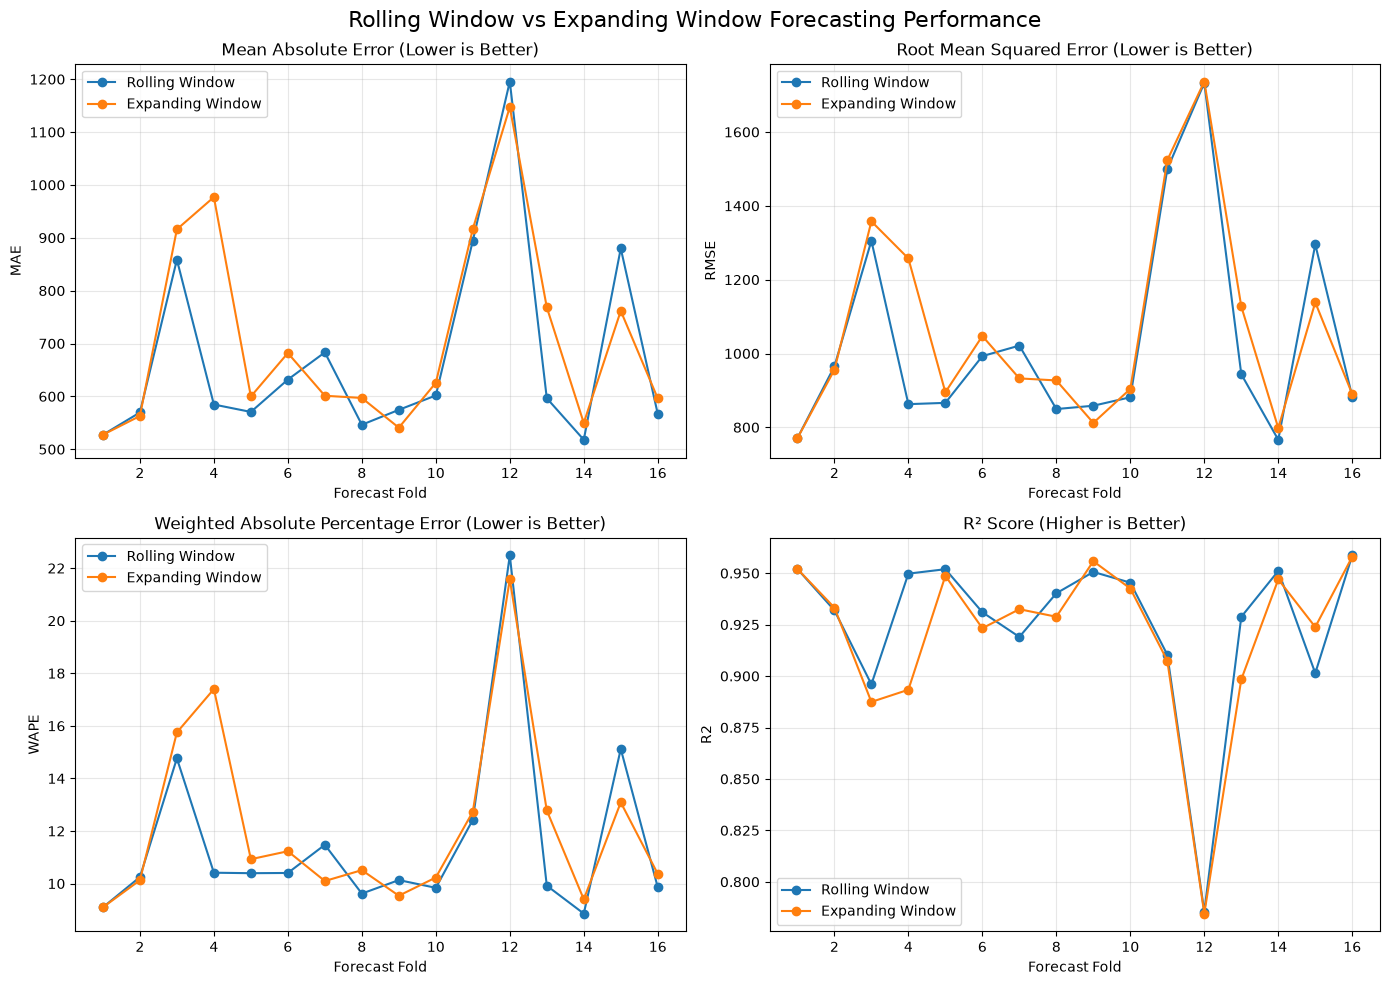

In [40]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ["MAE", "RMSE", "WAPE", "R2"]

titles = {
    "MAE": "Mean Absolute Error (Lower is Better)",
    "RMSE": "Root Mean Squared Error (Lower is Better)",
    "WAPE": "Weighted Absolute Percentage Error (Lower is Better)",
    "R2": "R² Score (Higher is Better)"
}

for ax, metric in zip(axes.flatten(), metrics):

    ax.plot(
        rolling_df["Fold"],
        rolling_df[metric],
        marker="o",
        label="Rolling Window"
    )

    ax.plot(
        expanding_df["Fold"],
        expanding_df[metric],
        marker="o",
        label="Expanding Window"
    )

    ax.set_title(titles[metric])
    ax.set_xlabel("Forecast Fold")
    ax.set_ylabel(metric)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(
    "Rolling Window vs Expanding Window Forecasting Performance",
    fontsize=16
)

plt.tight_layout()
plt.show()

| Metric   | Better value | What we're comparing                |
| -------- | -----------: | ----------------------------------- |
| **MAE**  |      Lower ↓ | Average absolute prediction error   |
| **RMSE** |      Lower ↓ | Penalizes large errors more heavily |
| **WAPE** |      Lower ↓ | Relative forecasting error          |
| **R²**   |     Higher ↑ | Variance explained by model         |


Around Fold 12, both models suddenly deteriorate:

MAE   ↑ dramatically

RMSE  ↑ dramatically

WAPE  ↑ dramatically

R²    ↓ dramatically

This is extremely important.

It tells us:

The forecasting difficulty is caused by something about the underlying demand period, not simply by the choice between Rolling and Expanding windows.



In [41]:

# FOLD 12 INVESTIGATION

fold_12 = rolling_folds[11]

fold12_forecast_start = fold_12["forecast_start"]
fold12_forecast_end = fold_12["forecast_end"]

fold12_future = development_df[
    (development_df["Date"] >= fold12_forecast_start) &
    (development_df["Date"] <= fold12_forecast_end)
].copy()

print("Fold 12 Forecast Period:")
print(fold12_forecast_start, "→", fold12_forecast_end)

print("\nFold 12 shape:", fold12_future.shape)

Fold 12 Forecast Period:
2014-12-27 00:00:00 → 2015-01-25 00:00:00

Fold 12 shape: (32550, 33)


In [42]:
print("FOLD 12 SALES STATISTICS")
print("=" * 40)

print(fold12_future["Sales"].describe())

FOLD 12 SALES STATISTICS
count    32550.000000
mean      5316.960184
std       3741.441617
min          0.000000
25%       3085.250000
50%       5452.000000
75%       7534.000000
max      32228.000000
Name: Sales, dtype: float64


Fold 12 has an unusually volatile sales pattern

Your Fold 12 covers:

27 Dec 2014 → 25 Jan 2015

The statistics are:

Statistic	Sales

Mean	5,316

Median	5,452

Std. Dev.	3,741

Minimum	0

Maximum	32,228

Q1	3,085

Q3	7,534

The most important observation is:

Std. Dev. = 3,741  compared with mean = 5,316

That's a very large amount of variation.

The maximum of 32,228 is more than 6× the mean, indicating that some store-days have exceptionally high sales.

Business insight

This means Fold 12 isn't simply a period where the model "performed badly." It contains highly irregular demand patterns, making forecasting inherently more difficult.

For a retail manager, this means:

normal demand is around 5.3K per store-day in the raw data,
but some store-days experience extreme spikes,
and a forecasting model optimized for normal patterns will naturally struggle with these exceptional observations.

In [43]:
zero_sales_count = (fold12_future["Sales"] == 0).sum()
zero_sales_percentage = (
    zero_sales_count / len(fold12_future) * 100
)

print("ZERO-SALES ANALYSIS")
print("=" * 40)

print("Zero-sales observations:", zero_sales_count)
print(f"Percentage: {zero_sales_percentage:.2f}%")

ZERO-SALES ANALYSIS
Zero-sales observations: 6708
Percentage: 20.61%


The 20.61% zero-sales rate is extremely important

You have:

6,708 zero-sales observations out of 32,550

= 20.61%

That's huge.

The total-sales graph shows a repeated pattern where sales suddenly collapse to almost zero and then recover sharply.

This suggests that store operating/closure patterns are generating structural zeros, rather than these being ordinary random forecasting errors.

Business insight

The model needs to understand:

"Zero sales" does not necessarily mean "zero customer demand." It can mean "the store was not operating."

In [44]:
daily_sales_fold12 = (
    fold12_future
    .groupby("Date")["Sales"]
    .sum()
    .reset_index()
)

print(daily_sales_fold12)

         Date     Sales
0  2014-12-27   5710292
1  2014-12-28    218071
2  2014-12-29   7291426
3  2014-12-30   7665743
4  2014-12-31   3895591
5  2015-01-01    130162
6  2015-01-02   7561431
7  2015-01-03   6150311
8  2015-01-04    197193
9  2015-01-05  11303805
10 2015-01-06   6791481
11 2015-01-07   8621857
12 2015-01-08   7646645
13 2015-01-09   7945387
14 2015-01-10   6277742
15 2015-01-11    183367
16 2015-01-12   9840664
17 2015-01-13   8538569
18 2015-01-14   7881690
19 2015-01-15   7774935
20 2015-01-16   8456148
21 2015-01-17   6525692
22 2015-01-18    195778
23 2015-01-19   6386391
24 2015-01-20   5744162
25 2015-01-21   5882045
26 2015-01-22   5933913
27 2015-01-23   6326166
28 2015-01-24   5811369
29 2015-01-25    179028


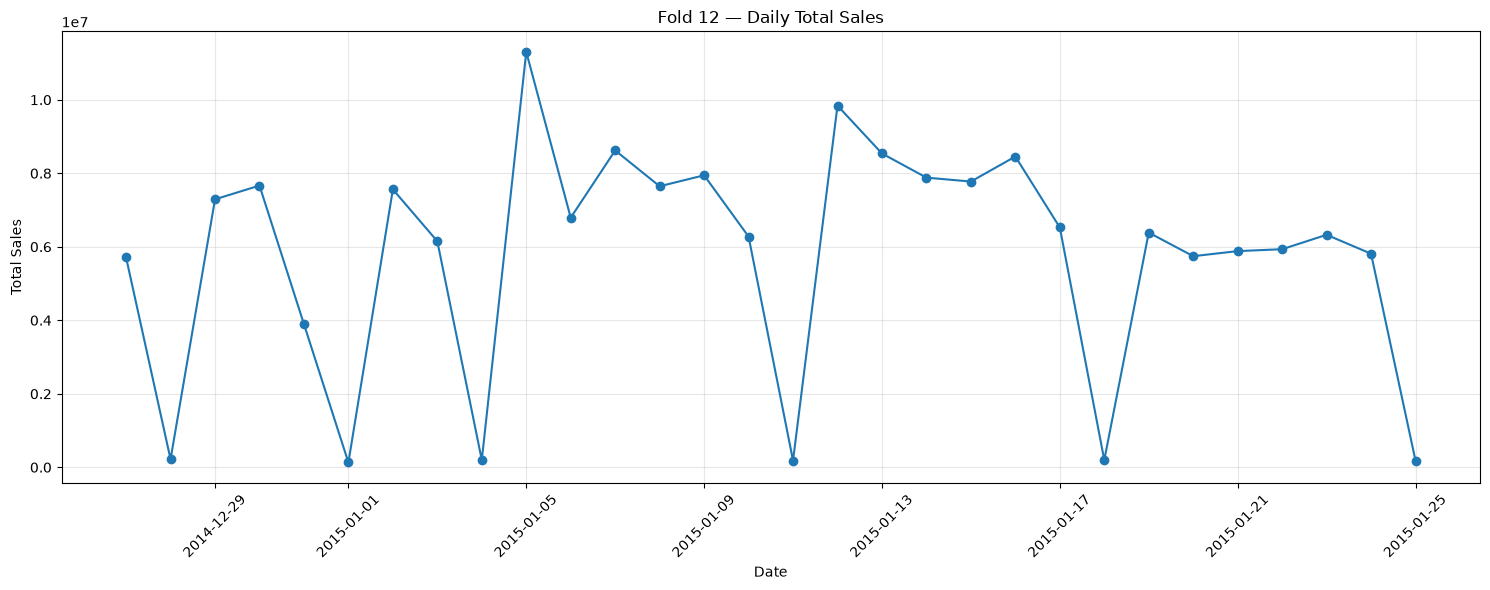

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales_fold12["Date"],
    daily_sales_fold12["Sales"],
    marker="o"
)

plt.title("Fold 12 — Daily Total Sales")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The Fold 12 graph shows strong weekly seasonality

There are repeated sharp drops followed by immediate recoveries.

For example:

high sales

→ almost zero

→ high sales again

→ moderate sales

→ almost zero

→ high sales

This repeating structure strongly suggests day-of-week / operating-calendar effects.

Business insight

A retail manager should not treat every calendar day equally.

Inventory, staffing and promotional planning should account for:

weekday vs weekend behavior

recurring weekly patterns

store operating schedules

holiday calendars.

In [46]:
print("SCHOOL HOLIDAY EFFECT")
print("=" * 40)

print(
    fold12_future
    .groupby("SchoolHoliday")["Sales"]
    .agg(
        Mean_Sales="mean",
        Median_Sales="median",
        Total_Sales="sum",
        Count="count"
    )
)

print("STATE HOLIDAY EFFECT")
print("=" * 40)

print(
    fold12_future
    .groupby("IsStateHoliday")["Sales"]
    .agg(
        Mean_Sales="mean",
        Median_Sales="median",
        Total_Sales="sum",
        Count="count"
    )
)

SCHOOL HOLIDAY EFFECT
                Mean_Sales  Median_Sales  Total_Sales  Count
SchoolHoliday                                               
0              5107.204142        5297.0    128466613  25154
1              6030.346268        6117.0     44600441   7396
STATE HOLIDAY EFFECT
                 Mean_Sales  Median_Sales  Total_Sales  Count
IsStateHoliday                                               
0               5548.843912        5607.0    172913074  31162
1                110.936599           0.0       153980   1388


School holidays actually increase sales

Your result:

School Holiday	Mean Sales

No	5,107

Yes	6,030

That's approximately:

5107

(6030−5107)×100≈18.1%

So sales are about 18% higher on average during school holidays.

This is a genuinely useful business insight.

Possible business explanation

During school holidays:

families have more free time,
shopping trips may increase,
foot traffic can increase,
consumer activity may shift toward retail stores.

Therefore:

School holidays appear to be a positive demand signal.

This also validates why SchoolHoliday should remain an important model feature.


State holidays have an extremely strong negative relationship with sales

Your output is striking:

State Holiday	Mean Sales
No	5,548.84
Yes	110.94

That's approximately a 98% reduction:

5548.84

(5548.84−110.94)×100≈98.0%

This is probably the strongest business signal in the entire investigation.

State holidays are associated with extremely low store-level sales, indicating that holiday/operational status is a critical determinant of realized sales.

That is a major characteristic of retail forecasting datasets.

In [47]:
import os

processed_dir = "../data/processed"

os.makedirs(processed_dir, exist_ok=True)

development_df.to_csv(
    os.path.join(
        processed_dir,
        "development_df.csv"
    ),
    index=False
)

print("Development dataset saved successfully.")
print("Shape:", development_df.shape)
print(
    "Date range:",
    development_df["Date"].min(),
    "to",
    development_df["Date"].max()
)

Development dataset saved successfully.
Shape: (915744, 33)
Date range: 2013-01-31 00:00:00 to 2015-05-31 00:00:00
